Non Preemptive Priority
PID  AT  BT  Priority  CT  TAT  WT
 P1   9   3         4  25   16  13
 P2   1   2         3   3    2   0
 P3   2   8         3  11    9   1
 P4  10   4         3  22   12   8
 P5   7   7         3  18   11   4

Average Waiting Time: 5.20
Average Turnaround Time: 10.00


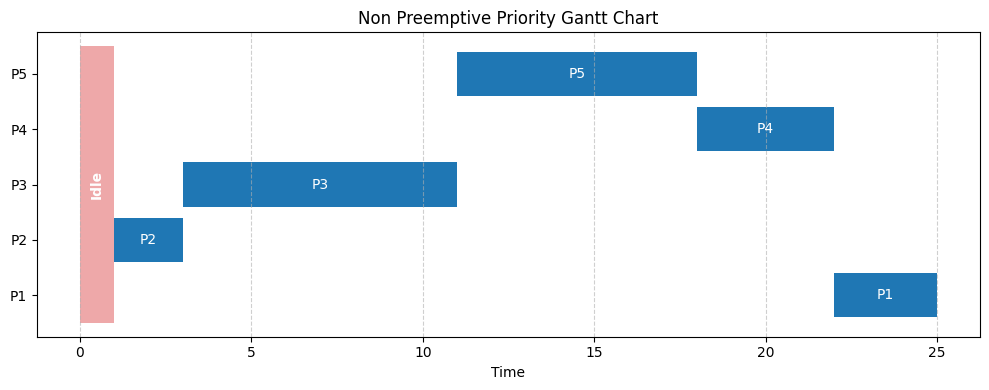

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd

n = int(input("Enter number of processes: "))

processes = []

for i in range(n):
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'Priority': random.randint(1, 5)  
    })

current_time = 0
total_tat = total_wt = 0
timeline = []
remaining = processes.copy()

while remaining:
    available = [p for p in remaining if p['AT'] <= current_time]

    if not available:
        next_time = min(p['AT'] for p in remaining)
        timeline.append(('Idle', current_time, next_time))
        current_time = next_time
        continue

    p = min(available, key=lambda x: (x['Priority'], x['AT']))

    start = current_time
    end = start + p['BT']

    p['CT'] = end
    p['TAT'] = end - p['AT']
    p['WT'] = p['TAT'] - p['BT']

    total_tat += p['TAT']
    total_wt += p['WT']

    timeline.append((p['PID'], start, end))
    current_time = end
    remaining.remove(p)

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print("Non Preemptive Priority")
print(df[['PID','AT','BT','Priority','CT','TAT','WT']].to_string(index=False))
print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
pids = df['PID'].unique()
y_pos = {pid: i for i, pid in enumerate(pids)}

for label, start, end in timeline:
    duration = end - start
    if duration == 0: continue
    
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(pids)), facecolors='tab:red', alpha=0.4)
        ax.text(start + duration/2, len(pids)/2 - 0.5, "Idle", ha='center', va='center', rotation=90, color='white', fontweight='bold')
    else:
        ax.broken_barh([(start, duration)], (y_pos[label]-0.4, 0.8), facecolors='tab:blue')
        ax.text((start+end)/2, y_pos[label], label, ha='center', va='center', color='white')

ax.set_yticks(range(len(pids)))
ax.set_yticklabels(pids)
ax.set_xlabel("Time")
ax.set_ylabel("Process ID")
ax.set_title("Non Preemptive Priority Gantt Chart")
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Non Preemptive Priority
PID  AT  BT  Priority  CT  TAT  WT
 P1   2   4         4   6    4   0
 P2   6   8         3  19   13   5
 P3   3   5         3  11    8   3
 P4   0   2         2   2    2   0
 P5   2   8         5  27   25  17
 P6   3  10         5  37   34  24

Average Waiting Time: 8.17
Average Turnaround Time: 14.33


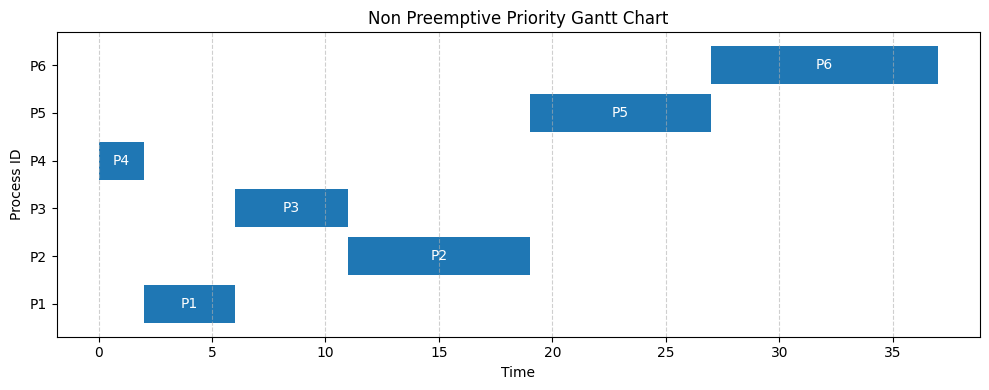

In [4]:
import random
import matplotlib.pyplot as plt
import pandas as pd

n = int(input("Enter number of processes: "))

processes = []

for i in range(n):
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'Priority': random.randint(1, 5)  
    })

current_time = 0
total_tat = total_wt = 0
timeline = []
remaining = processes.copy()

while remaining:
    available = [p for p in remaining if p['AT'] <= current_time]

    if not available:
        next_time = min(p['AT'] for p in remaining)
        timeline.append(('Idle', current_time, next_time))
        current_time = next_time
        continue

    p = min(available, key=lambda x: (x['Priority'], x['AT']))

    start = current_time
    end = start + p['BT']

    p['CT'] = end
    p['TAT'] = end - p['AT']
    p['WT'] = p['TAT'] - p['BT']

    total_tat += p['TAT']
    total_wt += p['WT']

    timeline.append((p['PID'], start, end))
    current_time = end
    remaining.remove(p)

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print("Non Preemptive Priority")
print(df[['PID','AT','BT','Priority','CT','TAT','WT']].to_string(index=False))
print(f"\nAverage Waiting Time: {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
pids = df['PID'].unique()
y_pos = {pid: i for i, pid in enumerate(pids)}

for label, start, end in timeline:
    duration = end - start
    if duration == 0: continue
    
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(pids)), facecolors='tab:red', alpha=0.4)
        ax.text(start + duration/2, len(pids)/2 - 0.5, "Idle", ha='center', va='center', rotation=90, color='white', fontweight='bold')
    else:
        ax.broken_barh([(start, duration)], (y_pos[label]-0.4, 0.8), facecolors='tab:blue')
        ax.text((start+end)/2, y_pos[label], label, ha='center', va='center', color='white')

ax.set_yticks(range(len(pids)))
ax.set_yticklabels(pids)
ax.set_xlabel("Time")
ax.set_ylabel("Process ID")
ax.set_title("Non Preemptive Priority Gantt Chart")
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
